## Section 1 - Load the data

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Section 2 - Inspection

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
df.isna().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

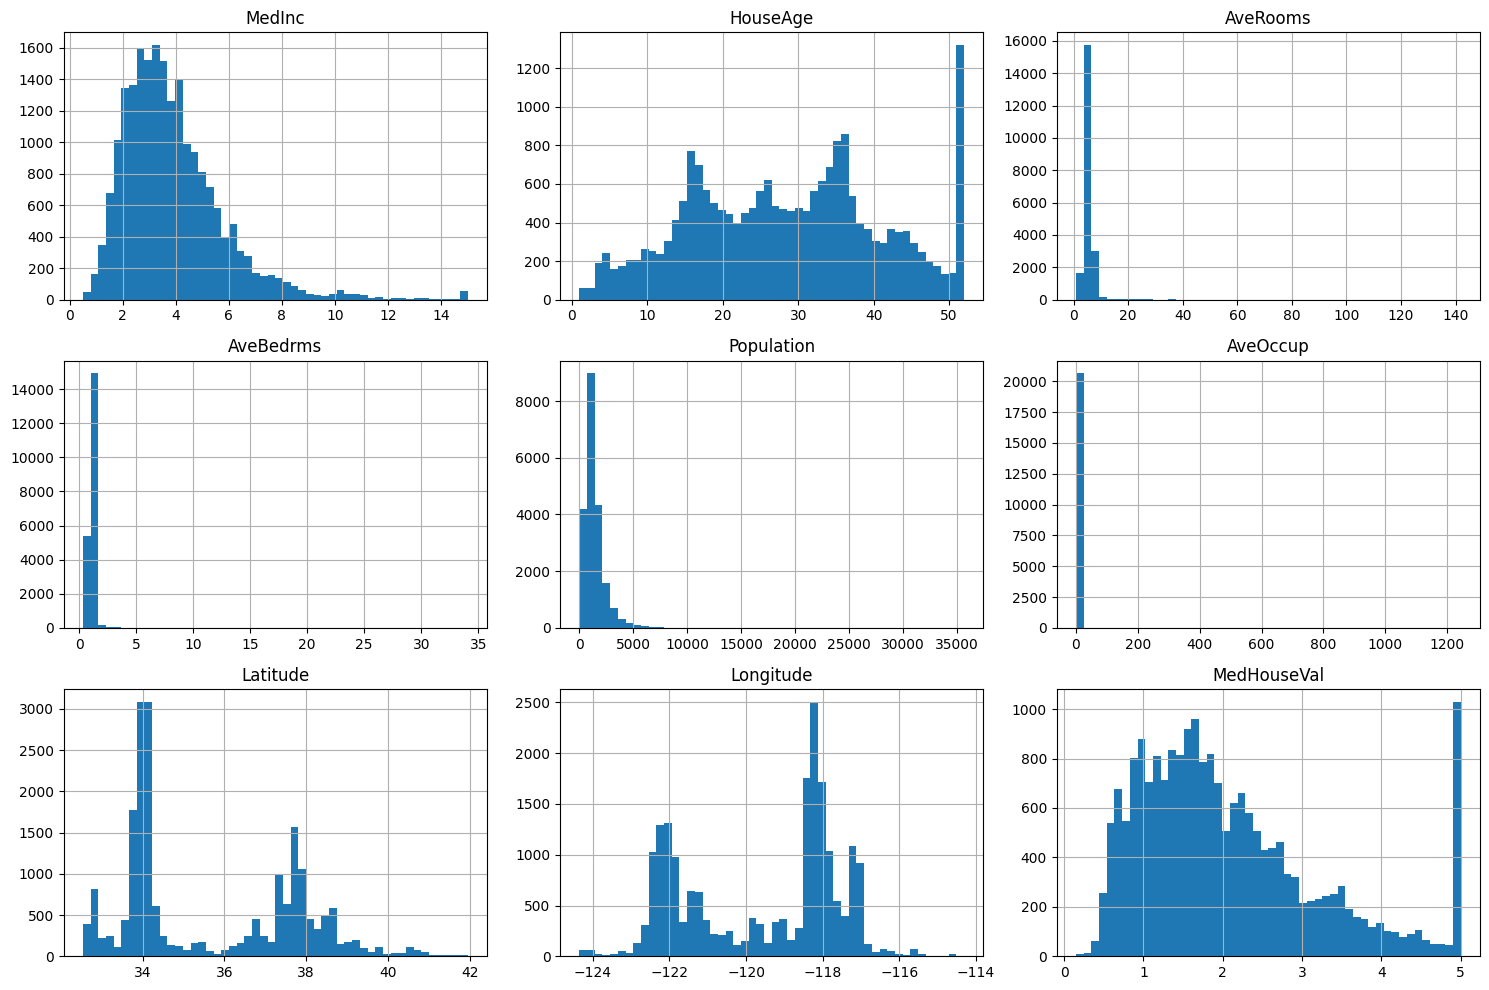

In [5]:
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [6]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

##### Observations from the Feature Distributions

- **`MedInc` (median income) is likely the feature most strongly correlated with `MedHouseVal`**, making it one of the most informative predictors for California housing prices in the 1990s.

- Several variables are **capped/truncated due to dataset collection limits**:
  - `HouseAge` capped at **52**
  - `MedHouseVal` capped at **5.0**
  - `MedInc` capped at approximately **15.0001** (upper bound) and **0.4999** (lower bound)
  
  These caps are known quirks of the original California census-derived dataset and can distort distributions near the boundaries.

- Features such as `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` show **extreme right-skewness** with long tails, suggesting highly uneven neighborhood characteristics.

- There are clear **outliers/anomalous districts**:
  - `AveOccup` exceeding **1000**
  - `Population` above **35,000**
  - `AveRooms` above **140**
  
  These values are unusually large for typical residential blocks and may require outlier handling or transformation.

- `Latitude` and `Longitude` show **clustered geographic patterns** rather than smooth distributions, which likely reflects dense population centers and coastal urban regions in California.

## Section 3 - Train/test split

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16512, 8), Test: (4128, 8)


- The test is set aside. It is not touched until the end of the model evaluation. Looking at it during development causes data leakage.

## Section 4 - Baseline linear regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Train RMSE: {rmse_train:.4f}")

Train RMSE: 0.7197


- The training **RMSE** is *0.7197*, and since the target variable is measured units of *100,000*, this corresponds to an average prediction error of about *71,970* for a typical house. In practical terms, the model's predicted median house value is usually off by roughly *$72k* from the actual value.